# Customer Churn Prediction Model

This notebook focuses on building machine learning models to predict customer churn and identify the key factors contributing to customer attrition.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation for Machine Learning

Remove non-predictive columns and prepare the dataset for model training.

In [3]:
df = pd.read_csv("churn_cleaned.csv")

print(df.shape)
df.head()

(7032, 24)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,Churn Reason,Tenure Group
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,86,3239,Competitor made better offer,0-12
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,67,2701,Moved,0-12
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,99.65,820.50,1,86,5372,Moved,0-12
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,104.80,3046.05,1,84,5003,Moved,24-48
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,89,5340,Competitor had better devices,48-72


In [4]:
df.columns.tolist()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason',
 'Tenure Group']

## Feature Selection

Remove target leakage variables and prepare the dataset for machine learning.

In [5]:
df_model = df.copy()

columns_to_drop = [
    'Churn Reason',
    'Churn Score'
]

df_model = df_model.drop(columns=columns_to_drop)

df_model.shape

(7032, 22)

## Define Features and Target Variable

In [6]:
X = df_model.drop('Churn Value', axis=1)

y = df_model['Churn Value']

print(X.shape)
print(y.shape)

(7032, 21)
(7032,)


## Encode Categorical Variables

Convert categorical variables into machine-learning-friendly numerical features.

In [7]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

X_encoded.shape

(7032, 34)

In [8]:
X_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,CLTV,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Tenure Group_12-24,Tenure Group_24-48,Tenure Group_48-72
0,2,53.85,108.15,3239,True,False,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
1,2,70.70,151.65,2701,False,False,False,True,True,False,...,False,False,False,True,False,True,False,False,False,False
2,8,99.65,820.50,5372,False,False,False,True,True,False,...,True,False,False,True,False,True,False,False,False,False
3,28,104.80,3046.05,5003,False,False,True,True,True,False,...,True,False,False,True,False,True,False,False,True,False
4,49,103.70,5036.30,5340,True,False,False,True,True,False,...,True,False,False,True,False,False,False,False,False,True


In [9]:
X_encoded.shape

(7032, 34)

## Train-Test Split

Split the dataset into training and testing sets to evaluate model performance on unseen data.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 34)
X_test : (1407, 34)
y_train: (5625,)
y_test : (1407,)


## Feature Scaling

Standardize numerical features for Logistic Regression.

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

In [17]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

## Model Evaluation

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_log))

Accuracy : 0.7974413646055437
Precision: 0.6369230769230769
Recall   : 0.553475935828877
F1 Score : 0.592274678111588
ROC AUC  : 0.8421993984604313


## Confusion Matrix

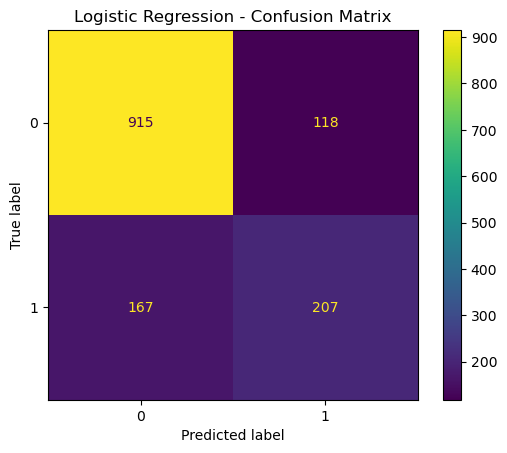

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### Logistic Regression Results

The Logistic Regression model achieved an accuracy of 79.7% and a ROC-AUC score of 84.2%, demonstrating strong ability to distinguish between customers who churn and those who remain.

While overall model performance is strong, recall indicates that approximately 55% of actual churners were correctly identified. This suggests that additional modeling techniques may further improve the identification of at-risk customers.

The model provides a solid baseline for customer churn prediction and serves as a benchmark for comparison with more advanced machine learning models.

## Random Forest Model

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [20]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.7945984363894811
Precision: 0.6421404682274248
Recall   : 0.5133689839572193
F1 Score : 0.5705794947994056
ROC AUC  : 0.8446337700793597


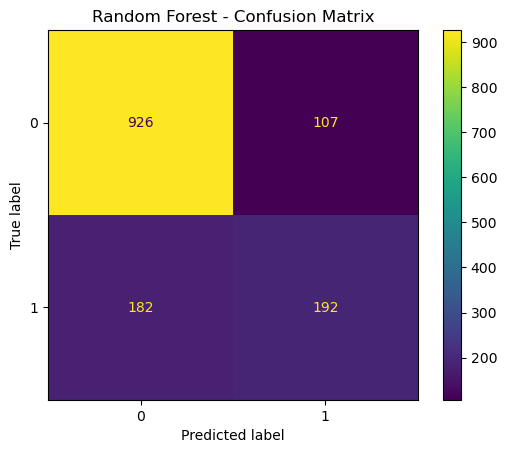

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [22]:
coef_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': log_model.coef_[0]
})

coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])

coef_df = coef_df.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient
0,Tenure Months,-1.287588,1.287588
7,Dependents_Yes,-0.688826,0.688826
26,Contract_Two year,-0.641787,0.641787
11,Internet Service_Fiber optic,0.592338,0.592338
1,Monthly Charges,-0.511667,0.511667
25,Contract_One year,-0.342317,0.342317
2,Total Charges,0.310066,0.310066
33,Tenure Group_48-72,0.261021,0.261021
22,Streaming TV_Yes,0.226515,0.226515
10,Multiple Lines_Yes,0.218359,0.218359


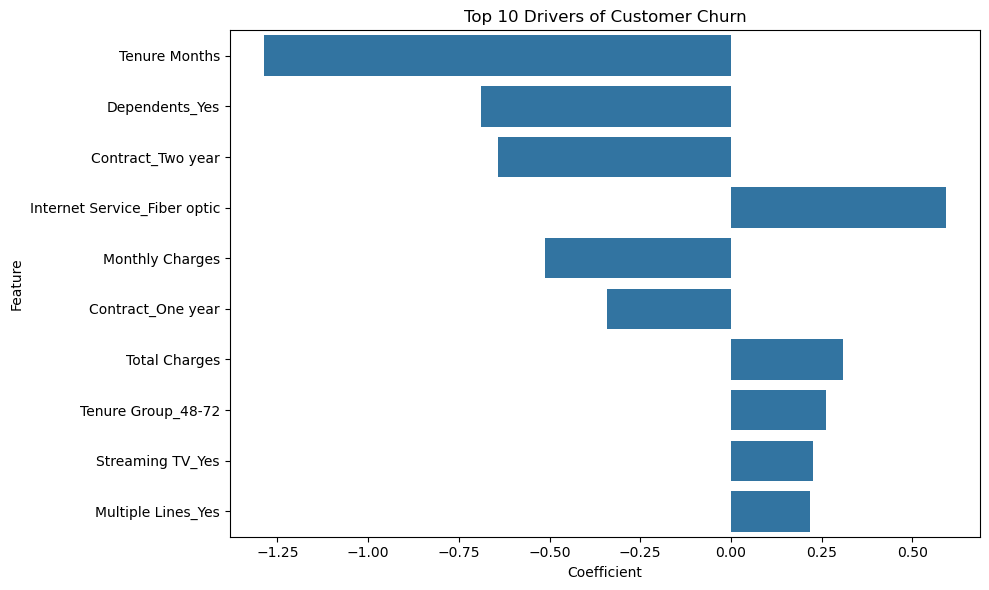

In [23]:
top_features = coef_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature'
)

plt.title('Top 10 Drivers of Customer Churn')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

## Feature Importance Analysis

Feature importance analysis helps identify the factors that contribute most significantly to customer churn.

Positive coefficients indicate factors associated with a higher likelihood of churn, while negative coefficients indicate factors associated with customer retention.

Understanding these drivers enables organizations to design targeted retention strategies and reduce customer attrition.

## Key Predictors of Customer Churn

Feature importance analysis revealed that customer tenure, contract type, and internet service are the strongest predictors of customer churn.

Customers with longer tenure and long-term contracts demonstrated significantly lower churn probability, highlighting the importance of customer retention and contract commitment strategies.

Customers using Fiber Optic internet services showed a higher likelihood of churn, suggesting potential opportunities to investigate pricing, service quality, or competitor offerings.

Monthly charges also emerged as an important factor, indicating that pricing and perceived value play a significant role in customer retention decisions.

These findings support the development of targeted retention programs focused on new customers, month-to-month subscribers, and customers with higher monthly charges.

## Model Comparison

Two machine learning models were evaluated for churn prediction.

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---------|---------|---------|---------|---------|---------|
| Logistic Regression | 79.7% | 63.7% | 55.3% | 59.2% | 84.2% |
| Random Forest | 79.5% | 64.2% | 51.3% | 57.1% | 84.5% |

Although both models performed similarly, Logistic Regression achieved higher recall and F1 Score, making it more effective at identifying customers likely to churn.

Because customer retention initiatives depend on detecting potential churners, Logistic Regression was selected as the preferred model for this project.

## ROC Curve Analysis

The Receiver Operating Characteristic (ROC) Curve evaluates the model's ability to distinguish between customers who are likely to churn and those who are likely to remain.

The Area Under the Curve (ROC-AUC) score summarizes the model's classification performance across all decision thresholds. A higher ROC-AUC value indicates better discrimination between churners and non-churners.

The Logistic Regression model achieved a ROC-AUC score of 84.2%, demonstrating strong predictive performance and effective identification of customers at risk of churn.

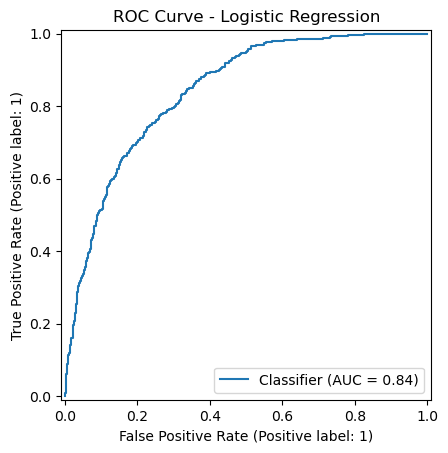

In [25]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

### ROC Curve Interpretation

The ROC curve shows that the model performs significantly better than random guessing and achieves strong separation between churning and non-churning customers.

With a ROC-AUC score of 84.2%, the model demonstrates strong predictive capability and can be used to support customer retention initiatives by identifying high-risk customers before they leave.